# 10 — Embeddings especializados para o RAG

Este notebook testa um encoder treinado para recuperação semântica e o compara, no mesmo conjunto de 32 consultas, com o BM25 e os resultados do notebook 09.

**Decisões:** usamos `intfloat/multilingual-e5-small`, prefixos `query:`/`passage:`, mean pooling com máscara e normalização L2. O modelo é pequeno o bastante para a RTX 3050 e o Colab. A seleção continua priorizando `Recall@5`, seguida de MRR e nDCG@5. O conjunto é pequeno e curado a partir da própria base; portanto o resultado é provisório.

**Objetivo e conexão com o projeto.** O experimento substitui o encoder genérico por um modelo treinado especificamente para recuperação semântica e o compara com os retrievers anteriores. Consultas e documentos recebem os prefixos esperados pelo E5; a escolha do vencedor usa o mesmo conjunto de avaliação, preservando a comparabilidade com a etapa 09.


## 1. Preparação do ambiente

Nesta célula são reunidos imports, parâmetros e caminhos necessários à etapa. Centralizar essa preparação antes do processamento deixa as dependências explícitas e evita que configurações importantes fiquem dispersas entre transformações, treinamento ou avaliação.


In [ ]:
from __future__ import annotations
import json, math, os, re, tempfile, time, unicodedata, warnings
from collections import Counter
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'wedjat-matplotlib'))
warnings.filterwarnings('ignore', message='IProgress not found.*')
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
SEED=42; MODEL_NAME='intfloat/multilingual-e5-small'; MAX_LENGTH=512; RRF_K=60
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE=16 if DEVICE.type=='cuda' else 4


### Função auxiliar: `find_root`

Esta célula isola a responsabilidade implementada por `find_root`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p/'data').exists() and (p/'notebooks').exists(): return p
    raise FileNotFoundError('Raiz do projeto não encontrada.')


### Preparação dos objetos desta etapa

A célula prepara `ROOT`, `KB_PATH`, `ALIASES_PATH`, `QUERIES_PATH` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [1]:
ROOT=find_root(); KB_PATH=ROOT/'data/knowledge_base/totvs_rag_kb_v1.json'
ALIASES_PATH=ROOT/'data/knowledge_base/rag_aliases.json'; QUERIES_PATH=ROOT/'data/knowledge_base/rag_evaluation_queries.json'
PREVIOUS_PATH=ROOT/'reports/metrics/rag_retrieval_evaluation.json'
REPORT_PATH=ROOT/'reports/metrics/sentence_embeddings_retrieval.json'
EMBEDDINGS_PATH=ROOT/'data/processed/rag_multilingual_e5_small_embeddings.npz'
FIGURE_PATH=ROOT/'reports/figures/sentence_embeddings_retrieval.png'
print({'device':str(DEVICE),'device_name':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'CPU','model':MODEL_NAME})


{'device': 'cuda', 'device_name': 'NVIDIA GeForce RTX 3050', 'model': 'intfloat/multilingual-e5-small'}


## 2. Dados e baseline lexical
A implementação lexical é mantida igual à do notebook 09 para que a comparação seja pareada e reproduzível.

Antes de transformar ou modelar, conferimos os dados usados nesta etapa e as condições que garantem comparabilidade. As verificações protegem a sequência do notebook contra arquivos incompletos e partições incompatíveis.


In [ ]:
kb=json.loads(KB_PATH.read_text(encoding='utf-8')); aliases=json.loads(ALIASES_PATH.read_text(encoding='utf-8'))['groups']
queries=json.loads(QUERIES_PATH.read_text(encoding='utf-8'))['queries']; previous=json.loads(PREVIOUS_PATH.read_text(encoding='utf-8'))
doc_ids=[d['id'] for d in kb]; assert all(set(q['expected_ids'])<=set(doc_ids) for q in queries)
STOP={'a','ao','aos','as','com','como','da','das','de','do','dos','e','em','entre','essa','esse','esta','este','foi','isso','mais','mas','muito','na','não','nas','no','nos','o','os','ou','para','pela','pelo','por','qual','que','se','sem','ser','sua','são','tem','um','uma','você','vs'}


### Função auxiliar: `norm`

Esta célula isola a responsabilidade implementada por `norm`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def norm(s):
    s=unicodedata.normalize('NFKD',str(s).casefold()); return ''.join(c for c in s if not unicodedata.combining(c))


### Preparação dos objetos desta etapa

A célula prepara `alias_variants` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
alias_variants=[[norm(x) for x in [g['canonical'],*g['aliases']]] for g in aliases]


### Funções auxiliares da seção

Esta célula agrupa `tokens`, `doc_text`, `weighted_tokens`, definições relacionadas que permanecem dentro de um bloco legível. Elas preparam operações específicas para as células seguintes e não processam dados até serem chamadas.


In [ ]:
def tokens(text, expand=True):
    n=norm(text); out=[x for x in re.findall(r'[a-z0-9+]+',n) if len(x)>=2 and x not in STOP]
    if expand:
        padded=f' {n} '
        for variants in alias_variants:
            if any(f' {v} ' in padded for v in variants): out.extend(tokens(' '.join(variants),False))
    return out
def doc_text(d):
    values=[d.get('title',''),d.get('product',''),d.get('category',''),' '.join(d.get('segments',[])),' '.join(d.get('keywords',[])),' '.join(d.get('related_products',[])),' '.join(d.get('competitors',[])),d.get('content','')]
    return '. '.join(str(x) for x in values if x)
def weighted_tokens(d):
    fields=[(d.get('title',''),3),(d.get('product',''),3),(' '.join(d.get('keywords',[])),2),(d.get('category',''),1),(' '.join(d.get('segments',[])),1),(' '.join(d.get('related_products',[])),1),(' '.join(d.get('competitors',[])),2),(d.get('content',''),1)]
    return [t for value,w in fields for t in tokens(value)*w]


### Preparação dos objetos desta etapa

A célula prepara `doc_tokens`, `tf`, `lengths`, `avg` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
doc_tokens=[weighted_tokens(d) for d in kb]; tf=[Counter(x) for x in doc_tokens]; lengths=np.array([len(x) for x in doc_tokens],float); avg=lengths.mean(); df=Counter()
for x in doc_tokens: df.update(set(x))


### Funções auxiliares da seção

Esta célula agrupa `bm25`, `rank`, definições relacionadas que permanecem dentro de um bloco legível. Elas preparam operações específicas para as células seguintes e não processam dados até serem chamadas.


In [ ]:
def bm25(query,k1=1.5,b=.75):
    scores=np.zeros(len(kb))
    for term in tokens(query):
        freq_docs=df.get(term,0)
        if not freq_docs: continue
        idf=math.log(1+(len(kb)-freq_docs+.5)/(freq_docs+.5))
        for i,freqs in enumerate(tf):
            f=freqs.get(term,0)
            if f: scores[i]+=idf*f*(k1+1)/(f+k1*(1-b+b*lengths[i]/avg))
    return scores
def rank(scores): return np.argsort(-scores,kind='stable').tolist()


### Preparação dos objetos desta etapa

A célula prepara `bm25_rankings` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [2]:
bm25_rankings=[rank(bm25(q['query'])) for q in queries]
print({'documents':len(kb),'queries':len(queries),'aliases':len(aliases)})


{'documents': 107, 'queries': 32, 'aliases': 29}


## 3. Embeddings E5
Consultas e documentos recebem prefixos diferentes, conforme o objetivo contrastivo do encoder. Não fazemos ajuste fino com as 32 consultas, evitando otimizar diretamente sobre o conjunto de avaliação.


In [ ]:
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME); model=AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()


### Função auxiliar: `embed`

Esta célula isola a responsabilidade implementada por `embed`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def embed(texts,prefix):
    vectors=[]; started=time.perf_counter()
    for start in range(0,len(texts),BATCH_SIZE):
        batch=[prefix+x for x in texts[start:start+BATCH_SIZE]]
        encoded=tokenizer(batch,padding=True,truncation=True,max_length=MAX_LENGTH,return_tensors='pt').to(DEVICE)
        with torch.inference_mode(), torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=DEVICE.type=='cuda'):
            hidden=model(**encoded).last_hidden_state
        mask=encoded['attention_mask'].unsqueeze(-1); pooled=(hidden.float()*mask).sum(1)/mask.sum(1).clamp(min=1)
        vectors.append(F.normalize(pooled,p=2,dim=1).cpu().numpy())
    return np.concatenate(vectors),time.perf_counter()-started


### Preparação dos objetos desta etapa

A célula prepara `dense_rankings` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
doc_embeddings,doc_seconds=embed([doc_text(d) for d in kb],'passage: ')
query_embeddings,query_seconds=embed([q['query'] for q in queries],'query: ')
EMBEDDINGS_PATH.parent.mkdir(parents=True,exist_ok=True); np.savez_compressed(EMBEDDINGS_PATH,document_ids=np.array(doc_ids),embeddings=doc_embeddings)
dense_rankings=[rank(scores) for scores in query_embeddings@doc_embeddings.T]


### Função auxiliar: `rrf`

Esta célula isola a responsabilidade implementada por `rrf`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def rrf(*rankings):
    scores=np.zeros(len(kb))
    for ranking in rankings:
        for pos,i in enumerate(ranking,1): scores[i]+=1/(RRF_K+pos)
    return scores


### Preparação dos objetos desta etapa

A célula prepara `hybrid_rankings` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [3]:
hybrid_rankings=[rank(rrf(b,d)) for b,d in zip(bm25_rankings,dense_rankings)]
print({'dimensions':doc_embeddings.shape[1],'document_seconds':round(doc_seconds,3),'query_seconds':round(query_seconds,3)})


C:\Users\Gabriel Pereira\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gabriel Pereira\.cache\huggingface\hub\models--intfloat--multilingual-e5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2377.49it/s]

{'dimensions': 384, 'document_seconds': 0.627, 'query_seconds': 0.032}


## 4. Avaliação, decisão e artefatos

As escolhas abaixo delimitam o experimento e devem ser lidas antes da implementação. Elas registram o que o código efetivamente faz e quais limitações precisam permanecer visíveis na interpretação.


In [ ]:
def evaluate(rankings):
    vals={k:[] for k in ['mrr','recall@1','hit@1','ndcg@1','recall@3','hit@3','ndcg@3','recall@5','hit@5','ndcg@5']}; details=[]
    for q,r in zip(queries,rankings):
        ids=[doc_ids[i] for i in r]; relevant=set(q['expected_ids']); positions=[i for i,x in enumerate(ids,1) if x in relevant]
        vals['mrr'].append(1/min(positions) if positions else 0); row={'query_id':q['id'],'expected_ids':sorted(relevant),'first_relevant_rank':min(positions) if positions else None,'top5_ids':ids[:5]}
        for k in (1,3,5):
            gains=[int(x in relevant) for x in ids[:k]]; recall=sum(gains)/len(relevant); dcg=sum(g/math.log2(i+2) for i,g in enumerate(gains)); ideal=sum(1/math.log2(i+2) for i in range(min(k,len(relevant))))
            vals[f'recall@{k}'].append(recall); vals[f'hit@{k}'].append(float(any(gains))); vals[f'ndcg@{k}'].append(dcg/ideal if ideal else 0); row[f'recall@{k}']=recall
        details.append(row)
    return {k:float(np.mean(v)) for k,v in vals.items()},details


### Construção da visualização

A célula converte as métricas já calculadas em uma comparação visual. Nenhuma decisão adicional é tomada aqui; o gráfico apenas torna os resultados mais fáceis de inspecionar.


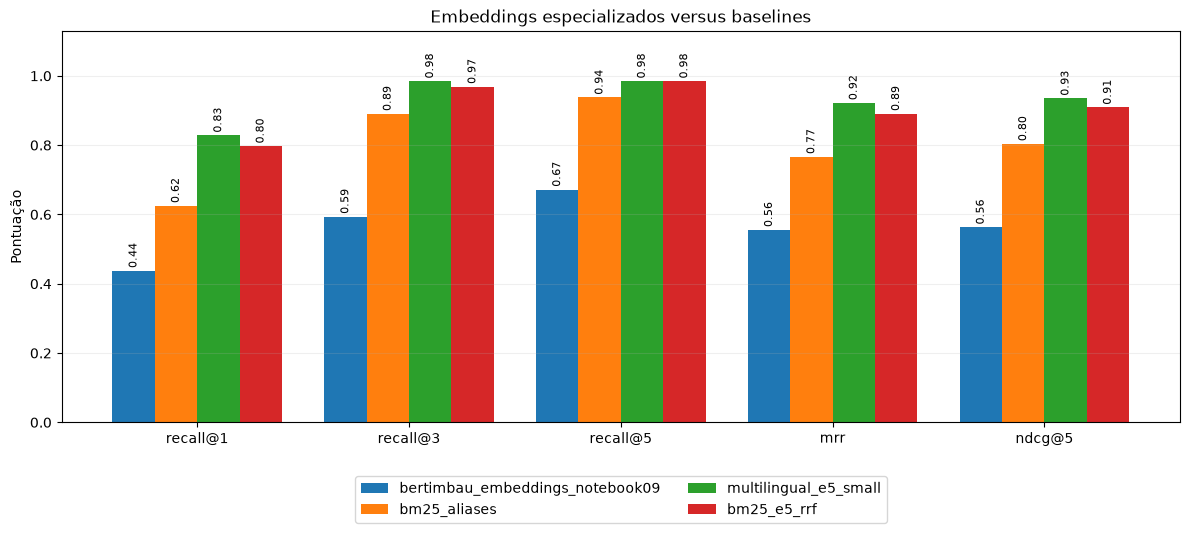

{'bm25_aliases': {'mrr': 0.7664, 'recall@1': 0.625, 'hit@1': 0.625, 'ndcg@1': 0.625, 'recall@3': 0.8906, 'hit@3': 0.9062, 'ndcg@3': 0.7841, 'recall@5': 0.9375, 'hit@5': 0.9688, 'ndcg@5': 0.8036}, 'multilingual_e5_small': {'mrr': 0.9219, 'recall@1': 0.8281, 'hit@1': 0.8438, 'ndcg@1': 0.8438, 'recall@3': 0.9844, 'hit@3': 1.0, 'ndcg@3': 0.9347, 'recall@5': 0.9844, 'hit@5': 1.0, 'ndcg@5': 0.9347}, 'bm25_e5_rrf': {'mrr': 0.8906, 'recall@1': 0.7969, 'hit@1': 0.8125, 'ndcg@1': 0.8125, 'recall@3': 0.9688, 'hit@3': 1.0, 'ndcg@3': 0.9004, 'recall@5': 0.9844, 'hit@5': 1.0, 'ndcg@5': 0.9086}}
{'best_retriever': 'multilingual_e5_small', 'report': 'reports\\metrics\\sentence_embeddings_retrieval.json'}


In [4]:
rankings={'bm25_aliases':bm25_rankings,'multilingual_e5_small':dense_rankings,'bm25_e5_rrf':hybrid_rankings}
metrics={}; details={}
for name,value in rankings.items(): metrics[name],details[name]=evaluate(value)
best=max(metrics,key=lambda x:(metrics[x]['recall@5'],metrics[x]['mrr'],metrics[x]['ndcg@5']))
comparison={'bertimbau_embeddings_notebook09':previous['metrics']['bertimbau_embeddings'],**metrics}
names=list(comparison); keys=['recall@1','recall@3','recall@5','mrr','ndcg@5']; x=np.arange(len(keys)); width=.8/len(names)
fig,ax=plt.subplots(figsize=(12,6))
for i,name in enumerate(names):
    bars=ax.bar(x+(i-(len(names)-1)/2)*width,[comparison[name][k] for k in keys],width,label=name); ax.bar_label(bars,fmt='%.2f',padding=2,fontsize=8,rotation=90)
ax.set_xticks(x,keys); ax.set_ylim(0,1.13); ax.set_ylabel('Pontuação'); ax.set_title('Embeddings especializados versus baselines'); ax.grid(axis='y',alpha=.2); ax.legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=2); fig.tight_layout(rect=(0,.08,1,1))
FIGURE_PATH.parent.mkdir(parents=True,exist_ok=True); fig.savefig(FIGURE_PATH,dpi=160,bbox_inches='tight'); plt.show()
report={'schema_version':'1.0','model':MODEL_NAME,'documents':len(kb),'evaluation_queries':len(queries),'selection_rule':'recall@5_then_mrr_then_ndcg@5','metrics':metrics,'notebook09_reference':previous['metrics'],'best_retriever':best,'query_details':details,'embedding':{'dimensions':int(doc_embeddings.shape[1]),'max_length':MAX_LENGTH,'device':str(DEVICE),'document_seconds':doc_seconds,'query_seconds':query_seconds},'warning':'Avaliação inicial curada a partir da própria base; requer revisão humana e novas consultas externas.'}
REPORT_PATH.parent.mkdir(parents=True,exist_ok=True); REPORT_PATH.write_text(json.dumps(report,ensure_ascii=False,indent=2)+'\n',encoding='utf-8')
print({name:{k:round(v,4) for k,v in values.items()} for name,values in metrics.items()}); print({'best_retriever':best,'report':str(REPORT_PATH.relative_to(ROOT))})


## 5. Interpretação
O vencedor é escolhido automaticamente e será consumido pelo notebook 11. Uma melhora neste conjunto não equivale a qualidade em produção: precisamos aumentar as consultas, revisá-las com especialistas e medir respostas ponta a ponta.

A leitura dos resultados deve considerar tanto o padrão observado quanto as limitações da referência. As conclusões desta seção orientam a próxima etapa, mas não substituem a validação humana prevista no projeto.
